# Linear Regresison

Goal: fitting provided data into a linear regression model.

In [1]:
# %pip install numpy matplotlib pandas seaborn scikit-learn

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

Text(0.5, 1.0, 'Synthetic Data for Linear Regression')

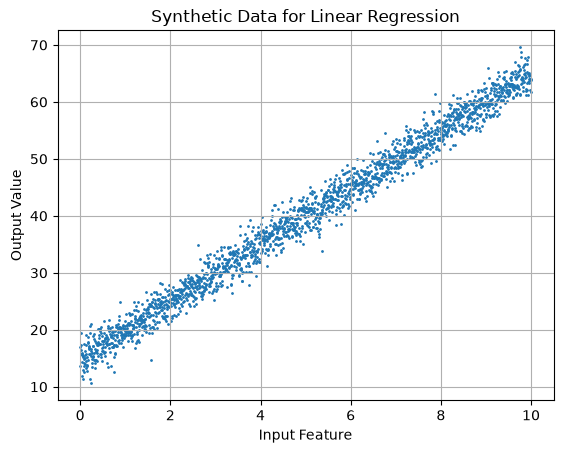

In [2]:
X = np.linspace(0, 10, 2000)
Y = 5 * X + 10 + np.random.normal(5, 2, len(X))
plt.scatter(X, Y, s=1)
plt.grid()
plt.xlabel('Input Feature')
plt.ylabel('Output Value')
plt.title('Synthetic Data for Linear Regression')

In [3]:
X_augmented = np.column_stack((np.ones(X.shape[0]), X))
print("Shape of augmented X:", X_augmented.shape)
print("First 5 rows of augmented X:\n", X_augmented[:5])

Shape of augmented X: (2000, 2)
First 5 rows of augmented X:
 [[1.         0.        ]
 [1.         0.0050025 ]
 [1.         0.010005  ]
 [1.         0.0150075 ]
 [1.         0.02001001]]


Split the data into training and testing data randomly (according to specified random seed for repreducability).
It's typical to use 80% of data for training and 20% of data for testing

In [4]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X_augmented, Y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (1600, 2)
Test set size: (400, 2)


Use all the training data to find the optimal parameters for the system (here named at W, in the notes, named Theta). Notice that the testing data is untouched here.

In [ ]:
#Train our weight matrix:

W = np.linalg.inv(X_train.T @ X_train) @ X_train.T @ Y_train
print("Trained weights:", W)

Trained weights: [14.96068139  5.01064284]


Compute a measure of the goodness of the model. In this case, our loss function is the MSE:
$MSE = \frac{1}{n} \sum_{j=1}^n{(\hat{y}^{(j)}-y^{(j)})^2}$

Mean Squared Error on Test Set: 3.5579237437875566


Text(0.5, 1.0, 'Linear Regression Prediction on Test Set')

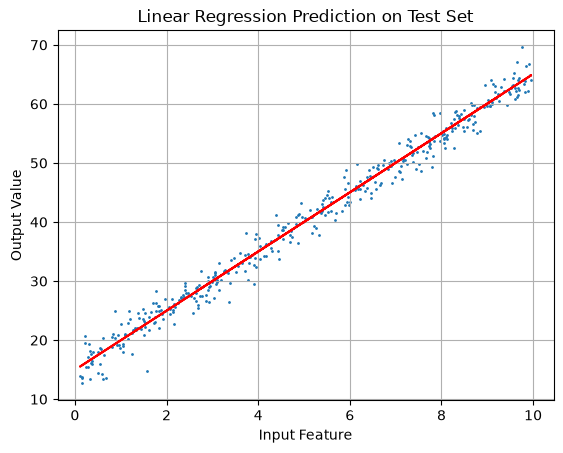

In [6]:
y_pred = X_test @ W
mse = np.mean((Y_test - y_pred) ** 2)
print("Mean Squared Error on Test Set:", mse)

plt.plot(X_test[:, 1], y_pred, color='red', label='Predicted Line')
plt.scatter(X_test[:, 1], Y_test, s=1, label='Test Data')
plt.grid()
plt.xlabel('Input Feature')
plt.ylabel('Output Value')
plt.title('Linear Regression Prediction on Test Set')

# Alternative Approach

Pre-existing python packages through sklearn. You do not need to do both approaches. You are welcome to use either approach (unless you the problems you are working on restrict you).

model coefficients:  [5.01064284]
model intercept:  14.960681392908526


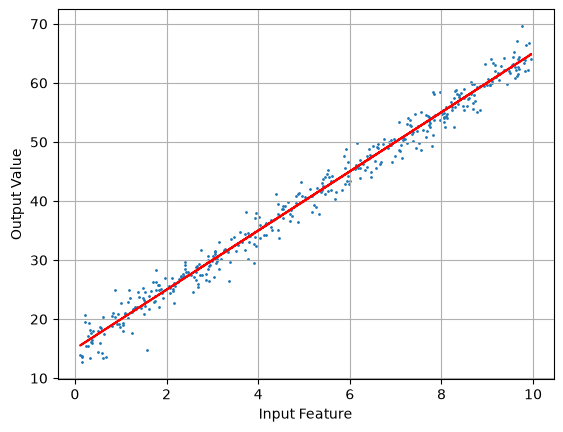

In [7]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train[:, 1].reshape(-1, 1), Y_train)
y_pred_sklearn = model.predict(X_test[:, 1].reshape(-1, 1))
mse_sklearn = np.mean((Y_test - y_pred_sklearn) ** 2)
plt.plot(X_test[:, 1], y_pred_sklearn, color='red', label='Sklearn Predicted Line')
plt.scatter(X_test[:, 1], Y_test, s=1, label='Test Data')
plt.grid()
plt.xlabel('Input Feature')
plt.ylabel('Output Value')
print("model coefficients: ", model.coef_)
print("model intercept: ", model.intercept_)

# Mutli-variate linear regression

The procedure remains the same. Your input vector is now a matrix. This time, our output parameter is a linear function of two inputs rather than one. In this case, we fit our data into a plane instead of a line.

Shape of X matrix: (2000, 2)
Mean Squared Error on Test Set: 0.2253079967017257
model coefficients:  [ 0.30358479 -0.79397038]
model intercept:  1.9928888131035172


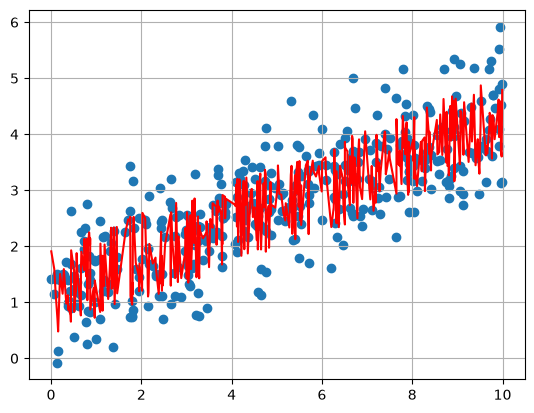

In [9]:
#inputs are drawn from a uniform distribution
X1 = np.random.uniform(0, 10, 2000)
X2 = np.random.uniform(0, 2, 2000)

# Actual output data
Y = .3*X1 - 0.8*X2 + 2 + np.random.normal(0, 0.5, len(X1))

X_mat = np.column_stack((X1, X2))
print("Shape of X matrix:", X_mat.shape)
X_train, X_test, Y_train, Y_test = train_test_split(
    X_mat, Y, test_size=0.2)

model = LinearRegression()
model.fit(X_train, Y_train)

#sort X_test in ascending order based on the first column
#unless I do this sorting, my line plot will be a complete mess
X_test_sorted_index = np.argsort(X_test[:, 0])
X_test_sorted = X_test[X_test_sorted_index]
Y_test_sorted = Y_test[X_test_sorted_index]
y_pred = model.predict(X_test_sorted)
mse = np.mean((Y_test_sorted - y_pred) ** 2)

print("Mean Squared Error on Test Set:", mse)
print("model coefficients: ", model.coef_)
print("model intercept: ", model.intercept_)

plt.scatter(X_test[:, 0], Y_test, label='Test Data')
plt.plot(X_test_sorted[:, 0], y_pred, color='red', label='Predicted Data')
plt.grid()

The code below is AI generated using the prompt "for the plots in the previous section, convert the plots to 3D plots that feature y vs X_1 and X_2" ChatGPT 5.6 Medium Terra was used.

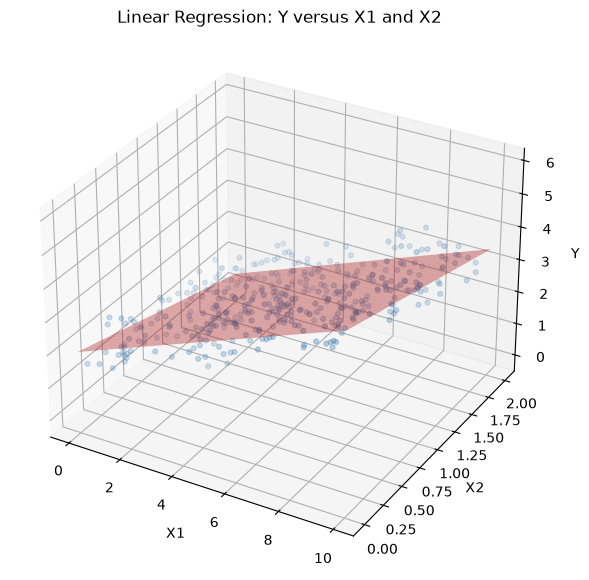

In [18]:
from mpl_toolkits.mplot3d import Axes3D  # enables 3D plotting

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

# Actual test observations
ax.scatter(
    X_test[:, 0], X_test[:, 1], Y_test,
    color="steelblue", s=12, alpha=0.6, label="Test data"
)

# Make a grid covering the X1–X2 input space
X1_grid, X2_grid = np.meshgrid(
    np.linspace(X1.min(), X1.max(), 50),
    np.linspace(X2.min(), X2.max(), 50)
)

# Convert grid points to the two-column format sklearn expects
X_grid = np.column_stack((
    X1_grid.ravel(),
    X2_grid.ravel()
))

# Predict y at every grid point, then restore the grid shape
Y_grid_pred = model.predict(X_grid).reshape(X1_grid.shape)

# Fitted regression plane
ax.plot_surface(
    X1_grid, X2_grid, Y_grid_pred,
    color="red", alpha=0.35
)

ax.set_xlabel("X1")
ax.set_ylabel("X2")
ax.set_zlabel("Y")
ax.set_title("Linear Regression: Y versus X1 and X2")

plt.show()